In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# !pip install --upgrade certifi

In [1]:
# !pip install gtts pydub audioop-lts
# !pip install --upgrade certifi # added certifi-2025.10.5, though check https://api.msedgeservices.com
import time
import os
import pandas as pd
from collections import defaultdict
from PIL import Image, ImageDraw, ImageFont
from moviepy import ImageClip
from utils_data import (
    load_raw_data, check_dups, filter_df_to_vocab_of_interest, 
    fill_default_settings, delete_previous_attempt_files
    )
from utils_video import (
    combine_clips_with_audio_to_create_video, create_icon_from_slide,
    draw_word_index, draw_logo, draw_previous_word, draw_previous_sent,
    draw_vocab_based_on_format, generate_intro_slide,
    generate_word_list_slide, generate_outro_slide,
    fill_default_video_configs
)
from utils_audio import (
    create_tts_files_for_one_vocab_word, compute_pinyin_and_create_recordings,
    combine_audio_files_and_compute_durations,
    generate_nonvocab_audio_and_compute_durations, create_final_audio_from_each_word_and_nonvocab
)
hanzi_font_path = '/System/Library/Fonts/STHeiti Medium.ttc'
pd.options.display.max_columns = 100
pd.options.display.max_rows = 130

In [ ]:
# reload configs
# from configs.vpg006_p1234567_idiom import (
# from configs.vpg004_p12345_k345_phrase import (
# from configs.vpg007_p5_2k345_words import (
# from configs.vpg005_p4_k2345_words import (
from configs.vpg002_p3_k345_words import (
    data_settings, output_path,
    video_configs,
    nonvocab_slides, subtitle_text_configs,
    DEFAULT_TEXT_PROPERTIES,
)
if subtitle_text_configs is not None:
    subtitle_text_configs['font'] = ImageFont.truetype(subtitle_text_configs['font_name'], subtitle_text_configs['font_size'])

In [3]:
truly_load_data = False
to_delete = False

# 0. Create dataframe of settings

In [4]:
# Fill in default data settings
data_settings = fill_default_settings(data_settings)

# Fill in default video configs
video_configs = fill_default_video_configs(video_configs)

# Create folder for non-audio recordings for this project
project_artifacts_folder = f"{output_path}{data_settings['recording_name']}"
data_settings['audio_path'] = f"{project_artifacts_folder}/audio_{data_settings['filename_suffix']}.mp3"
data_settings['video_path'] = f"{project_artifacts_folder}/video_{data_settings['filename_suffix']}.mp4"

# Create folder if not exists, and delete previous files if desired
if not os.path.exists(project_artifacts_folder):
    os.mkdir(project_artifacts_folder)
if to_delete:
    delete_previous_attempt_files(project_artifacts_folder, data_settings)

# Create folders for audio tts
voice_name_keys = ['voice_name_zh', 'voice_name_en', 'voice_name_convo']
for vnk in voice_name_keys:
    if vnk in data_settings:
        if isinstance(data_settings[vnk], dict):
            for speaker, voice_name in data_settings[vnk].items():
                tts_path = f"output/tts/{voice_name}"
                if not os.path.exists(tts_path):
                    os.mkdir(tts_path)
        else:
            voice_name = data_settings[vnk]
            tts_path = f"output/tts/{voice_name}"
            if not os.path.exists(tts_path):
                os.mkdir(tts_path)

data_settings

{'recording_id': 'ce_csent',
 'silent_components': True,
 'filename_suffix': 'p12_k2345_ce_csent',
 'voice_name_zh': 'zh-CN-XiaoxiaoNeural',
 'voice_name_en': 'en-US-AvaMultilingualNeural',
 'min_priority': 1,
 'max_priority': 2,
 'min_known_english_prompt': 2,
 'max_known_english_prompt': 5,
 'types_allowed': ['word',
  'prefix',
  'suffix',
  'abbreviation',
  'multi_word',
  'verb_ending',
  'proper noun'],
 'pause_between_words_ms': 800,
 'pause_start_ms': 200,
 'min_known_pinyin_prompt': 1,
 'max_known_pinyin_prompt': 6,
 'sort_keys': ['cat_v3',
  'cat2_v3',
  'cat3_v3',
  'category1',
  'category2',
  'pinyin'],
 'sort_asc': [True, True, True, True, True, True],
 'min_combo_quality': 10,
 'categories_allowed': None,
 'categories_not_allowed': None,
 'categories2_allowed': None,
 'categories2_not_allowed': None,
 'cat_v3_allowed': None,
 'cat_v3_not_allowed': None,
 'cat2_v3_allowed': None,
 'cat2_v3_not_allowed': None,
 'source1_values_allowed': None,
 'types_allowed_str': '',
 '

# 1. Load data

In [5]:
if truly_load_data:
    df_all_vocab = load_raw_data()
    df_all_vocab.to_csv('static/latest_data.csv', index=False)
else:
    df_all_vocab = pd.read_csv('static/latest_data.csv')
    print('!!!!!!!! WARNING: not truly loading data !!!!!!!!')

df_dups = check_dups(df_all_vocab)
print(df_all_vocab.shape)
df_all_vocab.head(3)

!!!!!!!! WARNING: not truly loading data !!!!!!!!
(8580, 39)


,id,chinese,pinyin,english,type,priority,category1,category2,cat_v3,cat2_v3,cat3_v3,hsk_level,known,known_pinyin_prompt,known_english_prompt,quality,word1,word1_english,word2,word2_english,word3,word3_english,word4,word4_english,voice_zh,voice_en,video_notes,idiom_literal,sentence,sentence_pinyin,sentence_english,date,source1,source2,funny,per,adu,slang,phonetic
0,1,房贷,fáng dài,mortgage,word,1.0,life,NaN,Finance & Economy,NaN,借贷与负债,MISSING,1.0,1.0,2.0,1.0,房子,house,贷款,loan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,他每个月都要还房贷,Ta měi gè yuè dōu yào huán fángdài,He has to pay his mortgage every month,2025-01-02,NaN,NaN,NaN,5.0,5.0,5.0,NaN
1,2,白天,bái tiān,daytime,word,2.0,time,NaN,Time,NaN,时间段 / 时长,1.0,2.0,1.0,1.0,1.0,白,white,天,day,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,白天很热晚上比较凉快,Báitiān hěn rè wǎnshàng bǐjiào liángkuai,It is hot in the daytime and cooler at night,2025-01-02,NaN,NaN,NaN,5.0,5.0,5.0,NaN
2,3,组成,zǔ chéng,to form;make up,word,3.0,general,NaN,Language & Expression,NaN,逻辑与结构,MISSING,5.0,5.0,5.0,3.0,组,set,成,become,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,水是由氢和氧组成的,Shuǐ shì yóu qīng hé yǎng zǔchéng de,Water is made up of hydrogen and oxygen,2025-01-02,NaN,NaN,NaN,5.0,5.0,5.0,NaN


In [6]:
print(f'# duplicate vocab: {len(df_dups)}')
df_dups

# duplicate vocab: 0


,id,chinese,pinyin,english,type,priority,category1,category2,cat_v3,cat2_v3,cat3_v3,hsk_level,known,known_pinyin_prompt,known_english_prompt,quality,word1,word1_english,word2,word2_english,word3,word3_english,word4,word4_english,voice_zh,voice_en,video_notes,idiom_literal,sentence,sentence_pinyin,sentence_english,date,source1,source2,funny,per,adu,slang,phonetic


# 2. Select data

In [7]:
df_vocab_lists = filter_df_to_vocab_of_interest(df_all_vocab, data_settings)
n_vocab = len(df_vocab_lists)
print(data_settings['recording_name'], n_vocab)
df_vocab_lists.head(3)

0601_ce_csent_p12_k2345_ce_csent 1318


,id,chinese,pinyin,english,type,priority,category1,category2,cat_v3,cat2_v3,cat3_v3,hsk_level,known,known_pinyin_prompt,known_english_prompt,quality,word1,word1_english,word2,word2_english,word3,word3_english,word4,word4_english,voice_zh,voice_en,video_notes,idiom_literal,sentence,sentence_pinyin,sentence_english,date,source1,source2,funny,per,adu,slang,phonetic
0,1611,青蛙,qīng wā,frog,word,2.0,animal,bug,Animals,NaN,两栖动物,MISSING,3.0,2.0,2.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,池塘里有一只青蛙,Chítáng lǐ yǒu yì zhī qīngwā,There is a frog in the pond,2025-01-02,NaN,NaN,NaN,5.0,5.0,5.0,NaN
1,4181,抚摸,fǔ mō,to pet;caress,word,2.0,animal,nonanimal,Animals,NaN,动物行为与动作,MISSING,5.0,4.0,5.0,2.0,抚慰,to soothe,摸,to touch (with hand),NaN,NaN,NaN,NaN,NaN,NaN,抚慰: to soothe\n摸: to touch (with hand),NaN,他轻轻抚摸小猫,Tā qīngqīng fǔmō xiǎo māo,He gently strokes the kitten,2025-07-28,daily add,NaN,NaN,5.0,5.0,5.0,NaN
2,3632,毛皮,máo pí,fur,word,2.0,animal,nonanimal,Animals,NaN,动物身体部位,MISSING,5.0,3.0,2.0,1.0,毛,hair,皮,skin,NaN,NaN,NaN,NaN,NaN,NaN,毛: hair\n皮: skin,NaN,毛皮外套很保暖,Máopí wàitào hěn bǎonuǎn,Fur coats are very warm,2025-05-29,my_topic,laundry_machine,NaN,5.0,5.0,5.0,NaN


# 3. Create vocabulary audio recordings

In [45]:
# # one-off
# from edge_tts import Communicate
# communicate = Communicate("Help", 'en-US-MichelleNeural')
# communicate.save_sync('tmp2.mp3')

In [8]:
# os.remove('output/tts/zh-CN-XiaoyuMultilingualNeural/今天下雨记得带雨衣.mp3')
if data_settings['recording_id'] == '005':
    df_vocab_lists = compute_pinyin_and_create_recordings(df_vocab_lists)

start_time = time.time()
for i_row, row in df_vocab_lists.iterrows():
    print(f"{(time.time()-start_time):.1f}s, row{i_row}")
    create_tts_files_for_one_vocab_word(row, data_settings)

0.0s, row0
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 青蛙
0.000s, ALREADY EXISTS, en-US-AvaMultilingualNeural, frog
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 池塘里有一只青蛙
0.0s, row1
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 抚摸
0.000s, ALREADY EXISTS, en-US-AvaMultilingualNeural, to pet;caress
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 他轻轻抚摸小猫
0.0s, row2
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 毛皮
0.000s, ALREADY EXISTS, en-US-AvaMultilingualNeural, fur
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 毛皮外套很保暖
0.0s, row3
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 尾巴
0.000s, ALREADY EXISTS, en-US-AvaMultilingualNeural, tail
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 猫的尾巴很长。
0.0s, row4
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 恐龙
0.000s, ALREADY EXISTS, en-US-AvaMultilingualNeural, dinosaur
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 恐龙早已在地球上灭绝
0.0s, row5
0.000s, ALREADY EXISTS, zh-CN-XiaoxiaoNeural, 郊狼
0.000s, ALREADY EXISTS, en-US-AvaMultilingualNeural, coyote
0.00

## 3b. Compute durations of combined audios for each vocab word

In [9]:
# os.remove('output/tts/zh-CN-XiaoxiaoNeural/蛇是典型的爬行动物。.mp3')

In [10]:
audio_duration_file_name = f"{project_artifacts_folder}/audio_durations_vocab_only.csv"
if os.path.exists(audio_duration_file_name):
    df_vocab_audio_durations = pd.read_csv(audio_duration_file_name)
    print(f"Loaded existing audio durations for {data_settings['recording_name']}, shape {df_vocab_audio_durations.shape}")
else:
    df_vocab_audio_durations = combine_audio_files_and_compute_durations(df_vocab_lists, data_settings)
    df_vocab_audio_durations.to_csv(audio_duration_file_name, index=False)

df_vocab_audio_durations['nonvocab_file_path'] = None
df_vocab_audio_durations['nonvocab_pause_ms'] = None
df_vocab_audio_durations['nonvocab_key'] = None
print(f"Total duration: {df_vocab_audio_durations['combined'].sum()}s")
df_vocab_audio_durations.head(3)

0.39 seconds, recid0601_ce_csent_p12_k2345_ce_csent, row 0, 青蛙
0.29 seconds, recid0601_ce_csent_p12_k2345_ce_csent, row 1, 抚摸
0.31 seconds, recid0601_ce_csent_p12_k2345_ce_csent, row 2, 毛皮
0.31 seconds, recid0601_ce_csent_p12_k2345_ce_csent, row 3, 尾巴
0.30 seconds, recid0601_ce_csent_p12_k2345_ce_csent, row 4, 恐龙
0.30 seconds, recid0601_ce_csent_p12_k2345_ce_csent, row 5, 郊狼
0.29 seconds, recid0601_ce_csent_p12_k2345_ce_csent, row 6, 山羊
0.30 seconds, recid0601_ce_csent_p12_k2345_ce_csent, row 7, 长颈鹿
0.35 seconds, recid0601_ce_csent_p12_k2345_ce_csent, row 8, 大象
0.32 seconds, recid0601_ce_csent_p12_k2345_ce_csent, row 9, 狮子
0.30 seconds, recid0601_ce_csent_p12_k2345_ce_csent, row 10, 兽医
0.30 seconds, recid0601_ce_csent_p12_k2345_ce_csent, row 11, 项圈
0.30 seconds, recid0601_ce_csent_p12_k2345_ce_csent, row 12, 飞虫
0.30 seconds, recid0601_ce_csent_p12_k2345_ce_csent, row 13, 蛇
0.30 seconds, recid0601_ce_csent_p12_k2345_ce_csent, row 14, 龙虾
0.34 seconds, recid0601_ce_csent_p12_k2345_ce_csen

,chinese,pinyin,english,sentence,sentence_pinyin,sentence_english,slang,phonetic,d_chinese,d_english,d_sent,rel_start_chinese,rel_start_english,rel_start_sent,sum_theory,combined,video_notes,nonvocab_file_path,nonvocab_pause_ms,nonvocab_key
0,青蛙,qīng wā,frog,池塘里有一只青蛙,Chítáng lǐ yǒu yì zhī qīngwā,There is a frog in the pond,5.0,NaN,1.224,1.056,2.160,0.2,1.924,3.480,6.440,6.439583,,None,None,None
1,抚摸,fǔ mō,to pet;caress,他轻轻抚摸小猫,Tā qīngqīng fǔmō xiǎo māo,He gently strokes the kitten,5.0,NaN,1.224,2.040,2.088,0.2,1.924,4.464,7.352,7.351583,抚慰: to soothe\n摸: to touch (with hand),None,None,None
2,毛皮,máo pí,fur,毛皮外套很保暖,Máopí wàitào hěn bǎonuǎn,Fur coats are very warm,5.0,NaN,1.248,0.864,2.160,0.2,1.948,3.312,6.272,6.271583,毛: hair\n皮: skin,None,None,None


# 4. Create non-vocab audio recordings

In [11]:
df_vocab_audio_durations, audio_filler_variables, nonvocab_slides = generate_nonvocab_audio_and_compute_durations(
    data_settings, df_vocab_audio_durations, nonvocab_slides, project_artifacts_folder)
df_vocab_audio_durations.head()

Generated 155分钟, 1318个单词


,chinese,pinyin,english,sentence,sentence_pinyin,sentence_english,slang,phonetic,d_chinese,d_english,d_sent,rel_start_chinese,rel_start_english,rel_start_sent,sum_theory,combined,video_notes,nonvocab_file_path,nonvocab_pause_ms,nonvocab_key,end,start,start_chinese,start_english,start_sent
0,"155分钟, 1318个单词","155 fēnzhōng, 1318 gè dāncí","155 minutes, 1318 words",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.530000,NaN,output/videos/0601_ce_csent_p12_k2345_ce_csent...,500,word_list,4.530000,0.000000,NaN,NaN,NaN
1,青蛙,qīng wā,frog,池塘里有一只青蛙,Chítáng lǐ yǒu yì zhī qīngwā,There is a frog in the pond,5.0,NaN,1.224,1.056,2.160,0.2,1.924,3.480,6.440,6.439583,,None,None,None,10.969583,4.530000,4.730000,6.454000,8.010000
2,抚摸,fǔ mō,to pet;caress,他轻轻抚摸小猫,Tā qīngqīng fǔmō xiǎo māo,He gently strokes the kitten,5.0,NaN,1.224,2.040,2.088,0.2,1.924,4.464,7.352,7.351583,抚慰: to soothe\n摸: to touch (with hand),None,None,None,18.321167,10.969583,11.169583,12.893583,15.433583
3,毛皮,máo pí,fur,毛皮外套很保暖,Máopí wàitào hěn bǎonuǎn,Fur coats are very warm,5.0,NaN,1.248,0.864,2.160,0.2,1.948,3.312,6.272,6.271583,毛: hair\n皮: skin,None,None,None,24.592750,18.321167,18.521167,20.269167,21.633167
4,尾巴,wěi ba,tail,猫的尾巴很长。,māo de wěi ba hěn cháng.,The cat’s tail is very long.,5.0,NaN,1.176,1.008,1.824,0.2,1.876,3.384,6.008,6.007583,,None,None,None,30.600333,24.592750,24.792750,26.468750,27.976750


# 5. Combine individual vocab into final audio recording

In [12]:
if not os.path.exists(data_settings['audio_path']):
    create_final_audio_from_each_word_and_nonvocab(df_vocab_audio_durations, data_settings)
else:
    print(f"Final audio already exists at {data_settings['audio_path']}")

155.88s, output/videos/0601_ce_csent_p12_k2345_ce_csent/audio_p12_k2345_ce_csent.mp3


# 6. Create images for video

In [13]:
# If don't want to rerun the above cells, then just run this cell to load the audio durations
audio_generation_previous_run = True
if audio_generation_previous_run:
    try:
        df_vocab_audio_durations = pd.read_csv(f"{project_artifacts_folder}/audio_durations_all.csv")
        print(f"{data_settings['recording_name']} loaded")
    except FileNotFoundError:
        print(f"File not found for recording {data_settings['recording_name']}, please run the cell above to generate audio durations.")
df_vocab_audio_durations.head()

0601_ce_csent_p12_k2345_ce_csent loaded


,chinese,pinyin,english,sentence,sentence_pinyin,sentence_english,slang,phonetic,d_chinese,d_english,d_sent,rel_start_chinese,rel_start_english,rel_start_sent,sum_theory,combined,video_notes,nonvocab_file_path,nonvocab_pause_ms,nonvocab_key,end,start,start_chinese,start_english,start_sent
0,"155分钟, 1318个单词","155 fēnzhōng, 1318 gè dāncí","155 minutes, 1318 words",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.530000,NaN,output/videos/0601_ce_csent_p12_k2345_ce_csent...,500.0,word_list,4.530000,0.000000,NaN,NaN,NaN
1,青蛙,qīng wā,frog,池塘里有一只青蛙,Chítáng lǐ yǒu yì zhī qīngwā,There is a frog in the pond,5.0,NaN,1.224,1.056,2.160,0.2,1.924,3.480,6.440,6.439583,NaN,NaN,NaN,NaN,10.969583,4.530000,4.730000,6.454000,8.010000
2,抚摸,fǔ mō,to pet;caress,他轻轻抚摸小猫,Tā qīngqīng fǔmō xiǎo māo,He gently strokes the kitten,5.0,NaN,1.224,2.040,2.088,0.2,1.924,4.464,7.352,7.351583,抚慰: to soothe\n摸: to touch (with hand),NaN,NaN,NaN,18.321167,10.969583,11.169583,12.893583,15.433583
3,毛皮,máo pí,fur,毛皮外套很保暖,Máopí wàitào hěn bǎonuǎn,Fur coats are very warm,5.0,NaN,1.248,0.864,2.160,0.2,1.948,3.312,6.272,6.271583,毛: hair\n皮: skin,NaN,NaN,NaN,24.592750,18.321167,18.521167,20.269167,21.633167
4,尾巴,wěi ba,tail,猫的尾巴很长。,māo de wěi ba hěn cháng.,The cat’s tail is very long.,5.0,NaN,1.176,1.008,1.824,0.2,1.876,3.384,6.008,6.007583,NaN,NaN,NaN,NaN,30.600333,24.592750,24.792750,26.468750,27.976750


## 6a. Vocab words

Drawing 0: 青蛙
Drawing 1: 抚摸
Drawing 2: 毛皮
Drawing 3: 尾巴
Drawing 4: 恐龙
Drawing 5: 郊狼
Drawing 6: 山羊
Drawing 7: 长颈鹿
Drawing 8: 大象
Drawing 9: 狮子
Drawing 10: 兽医
Drawing 11: 项圈
Drawing 12: 飞虫
Drawing 13: 蛇
Drawing 14: 龙虾
Drawing 15: 八爪鱼
Drawing 16: 负一楼
Drawing 17: 高楼大厦
Drawing 18: 水泥
Drawing 19: 设施
Drawing 20: 层
Drawing 21: 水龙头
Drawing 22: 台阶
Drawing 23: 花园
Drawing 24: 仓库
Drawing 25: 纪念碑
Drawing 26: 基础设施
Drawing 27: 城堡
Drawing 28: 大堂
Drawing 29: 扶梯
Drawing 30: 航站楼
Drawing 31: 厨房
Drawing 32: 凳子
Drawing 33: 盖
Drawing 34: 建设
Drawing 35: 街道
Drawing 36: 笼子
Drawing 37: 肯德基
Drawing 38: 麦当劳
Drawing 39: 全家便利店
Drawing 40: 瑞幸咖啡
Drawing 41: 沃尔玛
Drawing 42: 星巴克
Drawing 43: 喜茶
Drawing 44: 优衣库
Drawing 45: 进口
Drawing 46: 贸易
Drawing 47: 企业
Drawing 48: 生产
Drawing 49: 外贸
Drawing 50: 分公司
Drawing 51: 工程
Drawing 52: 电商
Drawing 53: 订单
Drawing 54: 工厂
Drawing 55: 合同
Drawing 56: 评价
Drawing 57: 标签
Drawing 58: 包邮
Drawing 59: 包装
Drawing 60: 非会员
Drawing 61: 很优惠
Drawing 62: 连锁店
Drawing 63: 品牌
Drawing 64: 商场
Drawing 65: 退货


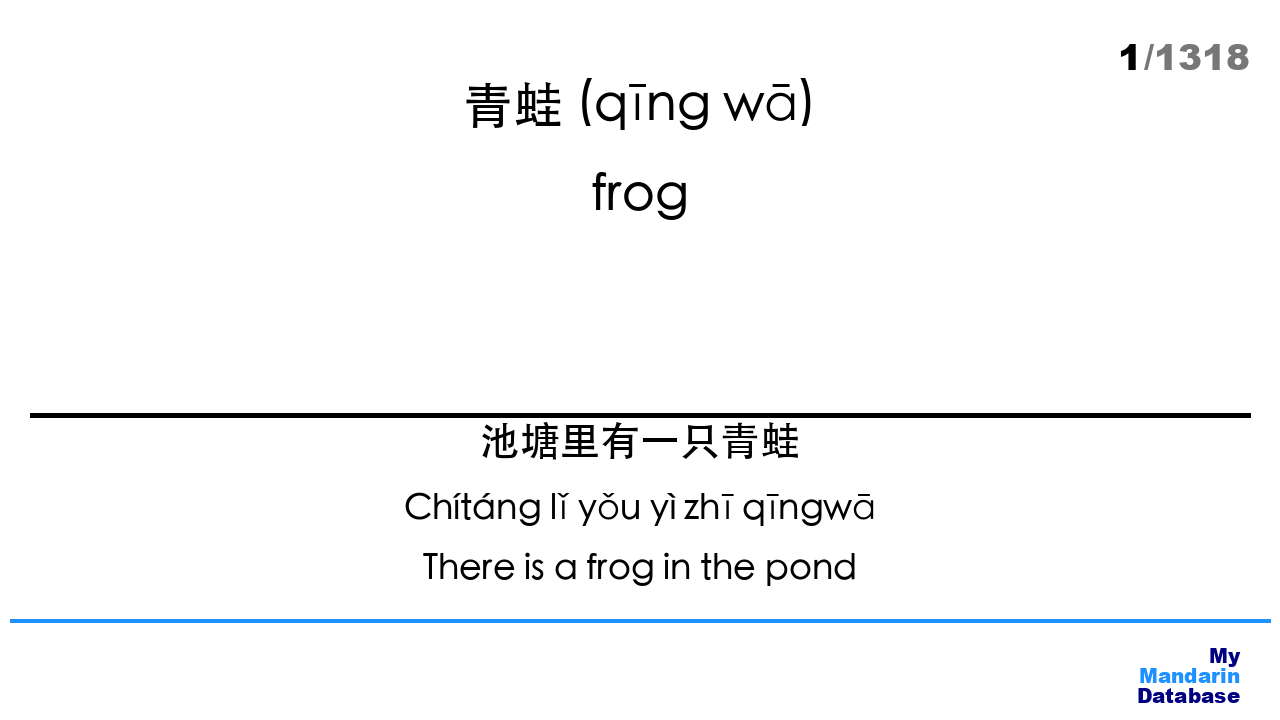

In [14]:
# Overall initializations
clips = []
previous_word = ''
previous_sent = ''

# Create folder to hold slide images
slides_path = f"{project_artifacts_folder}/slides"
if not os.path.exists(slides_path):
    os.mkdir(slides_path)

# Fill in defaults for any missing properties
for config_key, default_config_value in DEFAULT_TEXT_PROPERTIES.items():
    for vocab_slide_id, vocab_slide_settings in video_configs['vocab_slide'].items():
        if config_key not in vocab_slide_settings.keys():
            video_configs['vocab_slide'][vocab_slide_id][config_key] = default_config_value

# Iterate through each word
df_audio_durations_words_only = df_vocab_audio_durations.dropna(subset='sum_theory').reset_index(drop=True)
for word_idx, row in df_audio_durations_words_only.iterrows():
    # if row['chinese'] == '包裹':
    # Initialize image
    print(f'Drawing {word_idx}: {row["chinese"]}')
    current_image_file_path = f"{slides_path}/{row['chinese']}"
    img = Image.new("RGB", video_configs['bg_size'], color=video_configs['bg_color'])
    draw = ImageDraw.Draw(img)
    
    # Header/Footer texts
    draw_word_index(draw, video_configs, n_vocab, word_idx)
    if 'logo' in video_configs.keys():
        draw_logo(draw, video_configs)
    if 'previous_word' in video_configs.keys():
        draw_previous_word(draw, video_configs, previous_word)
    if 'previous_sent' in video_configs.keys():
        draw_previous_sent(draw, video_configs, previous_sent)
    draw.line([
        (video_configs['footer_line']['x'], video_configs['bg_size'][1] - video_configs['footer_line']['y']),
        (video_configs['bg_size'][0] - video_configs['footer_line']['x'], video_configs['bg_size'][1] - video_configs['footer_line']['y'])],
        fill=video_configs['footer_line']['color'],
        width=video_configs['footer_line']['width'],
        joint=None)
    
    # Update previous
    previous_word = f"{row['chinese']}\n{row['pinyin']}\n{row['english']}"
    if 'previous_sent' in video_configs.keys():
        previous_sent = f"{row['sentence']}\n{row['sentence_pinyin']}\n{row['sentence_english']}"

    # Draw vocab depending on recording ID
    # break
    draw_vocab_based_on_format(data_settings['recording_id'], row, video_configs, current_image_file_path, img, draw, clips)
    # break

my_img = clips[2]
my_img.display_in_notebook()

# 7. Create non-vocab slides


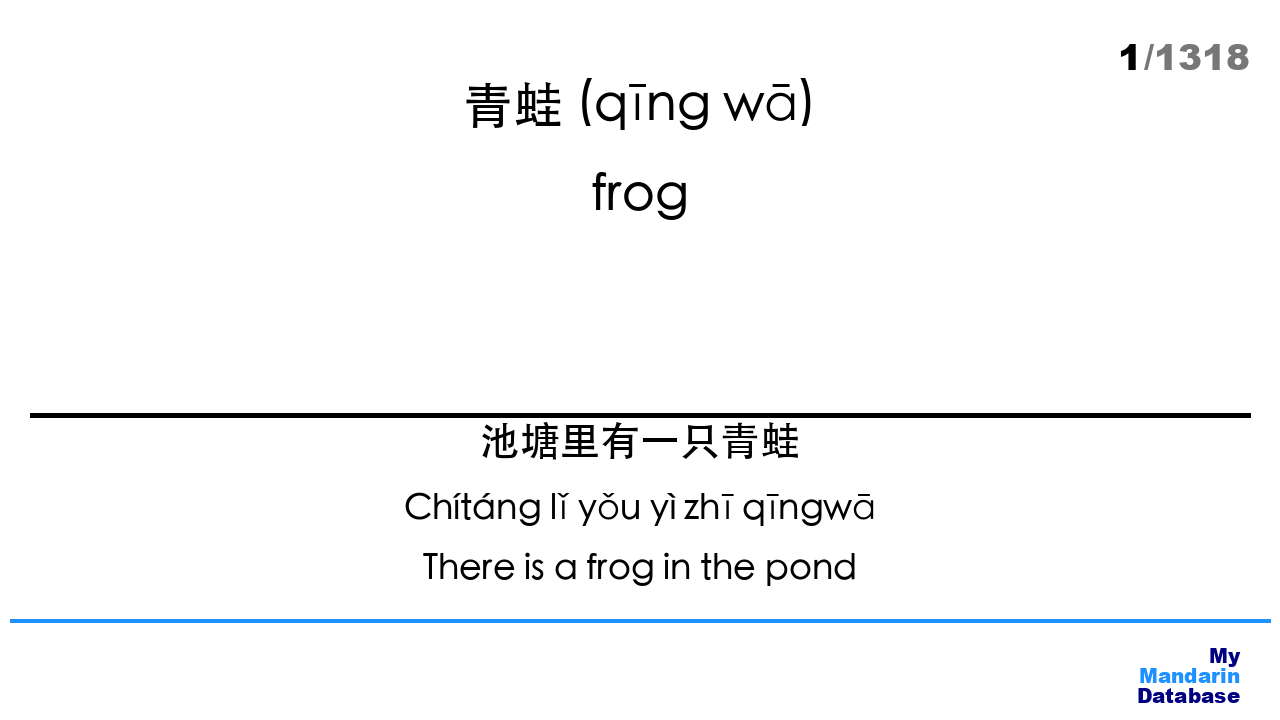

In [15]:
if nonvocab_slides is not None:
    if 'intro' in nonvocab_slides.keys():
        img = generate_intro_slide(video_configs, nonvocab_slides['intro'], subtitle_text_configs, audio_filler_variables)
        img.save(f"{project_artifacts_folder}/intro.png")
        my_img = ImageClip(f"{project_artifacts_folder}/intro.png", duration=1).with_start(0)
my_img.display_in_notebook()

reduced font size to 9
reduced font size to 8
reduced font size to 7
reduced font size to 9
reduced font size to 8
reduced font size to 7
reduced font size to 6
reduced font size to 9
reduced font size to 9
reduced font size to 9
reduced font size to 8
reduced font size to 7
reduced font size to 6
reduced font size to 9
reduced font size to 9
reduced font size to 8
reduced font size to 7
reduced font size to 9
reduced font size to 8
reduced font size to 7
reduced font size to 6
reduced font size to 9
reduced font size to 8
reduced font size to 7
reduced font size to 9
reduced font size to 8
reduced font size to 7
reduced font size to 6
reduced font size to 5
reduced font size to 9
reduced font size to 8
reduced font size to 7
reduced font size to 9
reduced font size to 8
reduced font size to 9
reduced font size to 9
reduced font size to 8
reduced font size to 7
reduced font size to 6
reduced font size to 9
reduced font size to 8
reduced font size to 7
reduced font size to 6
reduced fon


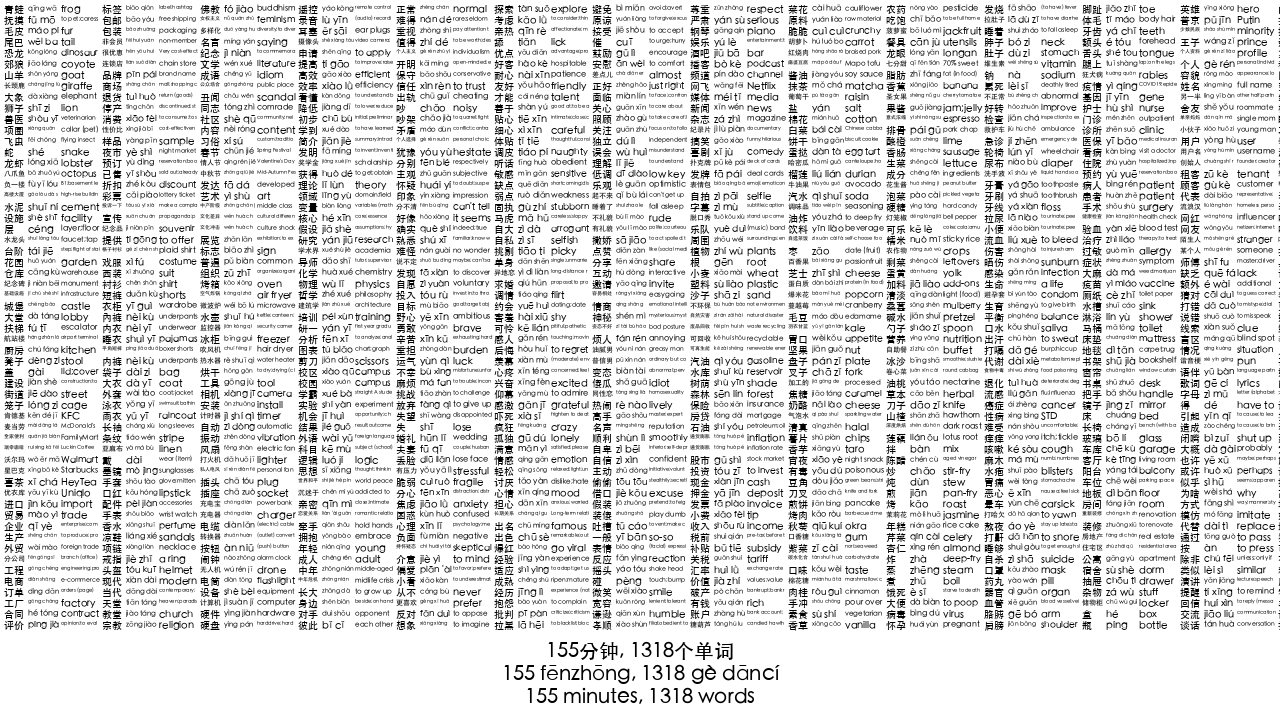

In [16]:
if nonvocab_slides is not None:
    if 'word_list' in nonvocab_slides.keys():
        img = generate_word_list_slide(video_configs, nonvocab_slides['word_list'], subtitle_text_configs, df_audio_durations_words_only)
        img.save(f"{project_artifacts_folder}/word_list.png")
        my_img = ImageClip(f"{project_artifacts_folder}/word_list.png", duration=1).with_start(0)
my_img.display_in_notebook()

In [17]:
# nonvocab_slides['outro'] = {
#         'chinese': '如果你有任何问题、建议或反馈，请留言。请点赞并订阅。',
#         'pinyin': 'Rúguǒ nǐ yǒu rènhé wèntí, jiànyì huò fǎnkuì, qǐng liúyán. Qǐng diǎn zàn bìng dìngyuè.',
#         'english': 'If you have any questions, suggestions, or feedback, please leave a comment. Please like and subscribe.',
#         'clip_index': -1,
#         'change_index': None,
#         'pause_ms': 500,

#         'y_top': 10,
#         'y_bottom': 70,
#         'x_top': 10,
#         'spacing': 0,
#         'font_size': 10,
#         'fill': '#FFFFFF',
#         'align': 'left',
#         'col_space': 0,
#         'col_space_big': 0,
#         'definition_configs':{
#             'chinese': {'x_offset': 0, 'x_max': 40, 'font_path': hanzi_font_path},
#             'english': {'x_offset': None, 'x_max': 115, 'font_path': hanzi_font_path},
#         }
# }


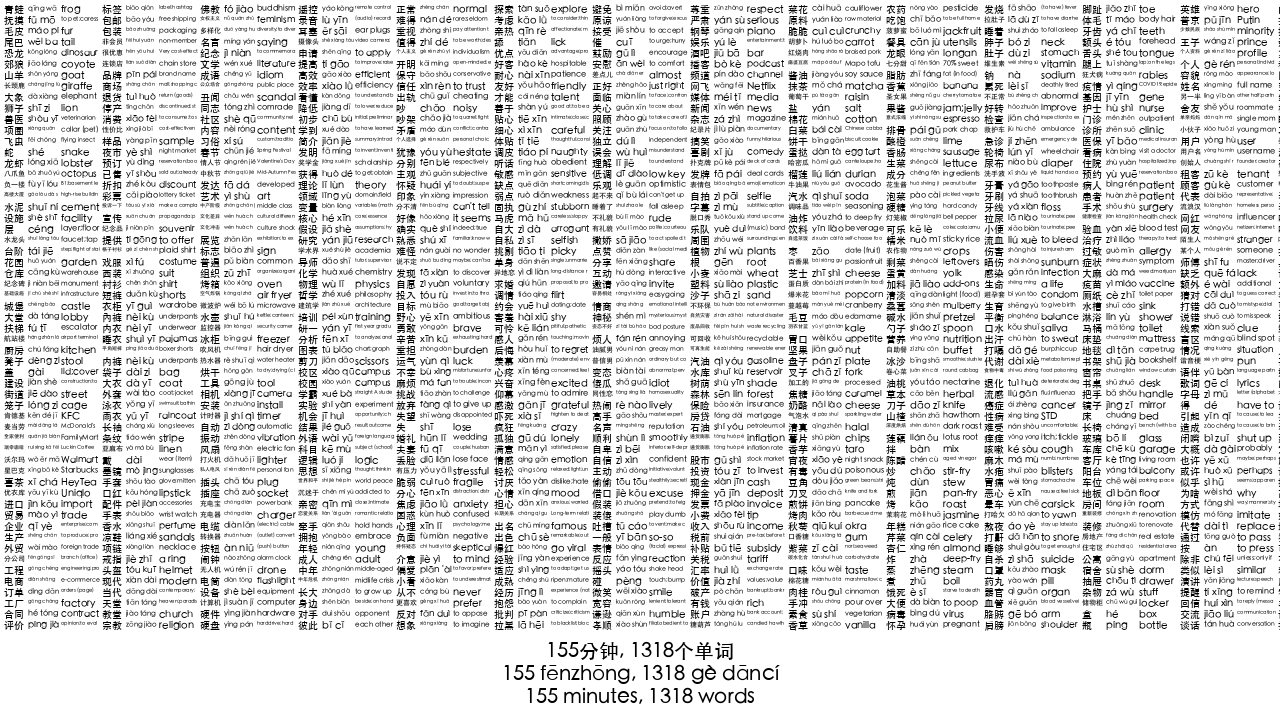

In [18]:
if nonvocab_slides is not None:
    if 'outro' in nonvocab_slides.keys():
        img = generate_outro_slide(video_configs, nonvocab_slides['outro'], subtitle_text_configs, df_audio_durations_words_only)
        img.save(f"{project_artifacts_folder}/outro.png")
        my_img = ImageClip(f"{project_artifacts_folder}/outro.png", duration=1).with_start(0)
my_img.display_in_notebook()

# 8. Create video icon


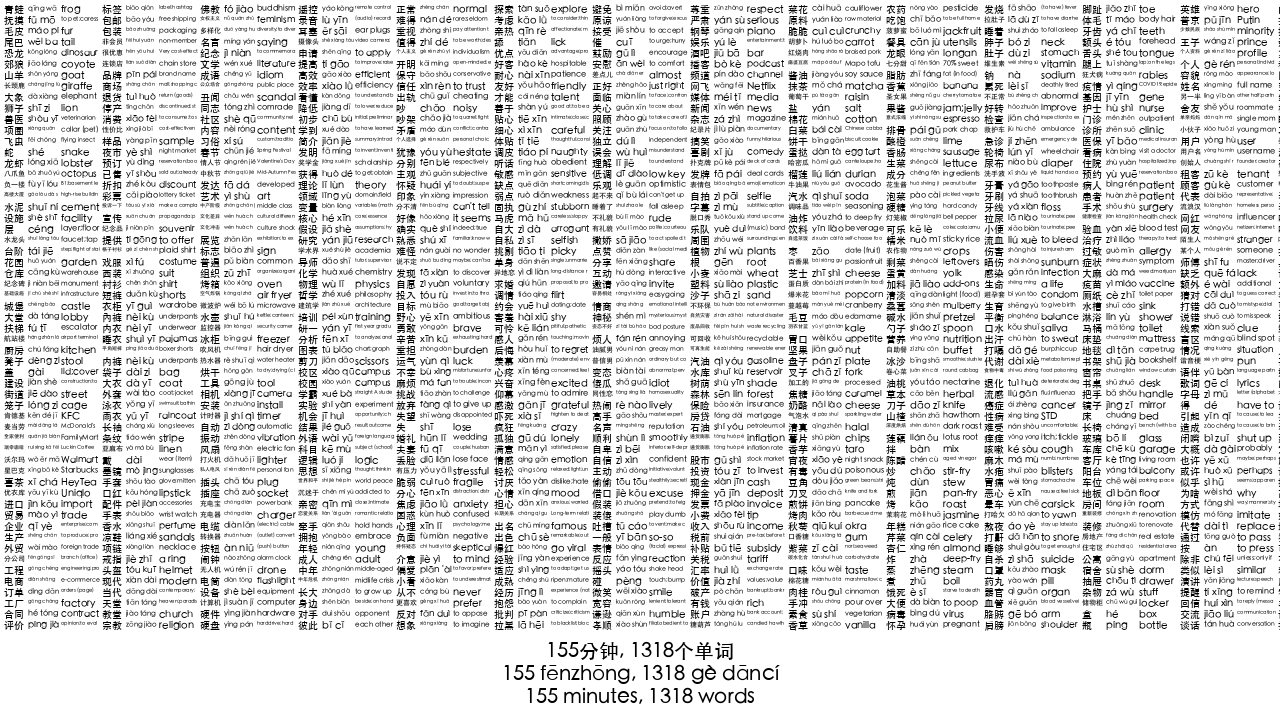

In [19]:
if 'icon_configs' in video_configs.keys():
    img = create_icon_from_slide(video_configs['icon_configs'], video_configs, project_artifacts_folder)
    img.save(f'{project_artifacts_folder}/icon.png')
    my_img = ImageClip(f"{project_artifacts_folder}/icon.png", duration=1).with_start(0)
my_img.display_in_notebook()

# 9. Create video

In [ ]:
combine_clips_with_audio_to_create_video(clips, nonvocab_slides, project_artifacts_folder, data_settings)

word_list
Number of clips: 3955
audio: 9297.170s, video: 9297.101s; difference: 0.069s
MoviePy - Building video output/videos/0601_ce_csent_p12_k2345_ce_csent/video_p12_k2345_ce_csent.mp4.
MoviePy - Writing audio in video_p12_k2345_ce_csentTEMP_MPY_wvf_snd.mp3


MoviePy - Done.
MoviePy - Writing video output/videos/0601_ce_csent_p12_k2345_ce_csent/video_p12_k2345_ce_csent.mp4



frame_index:  35%|███▍      | 77171/223132 [46:12<1:29:46, 27.10it/s, now=None]